In [98]:
%pip install -q matplotlib pandas==3.0.3 scikit-learn==1.9.0


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [76]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.constants import Column, MODEL_FEATURE_COLUMNS, OUTPUT_DIR

In [77]:
final_train_path = OUTPUT_DIR / "train" / "final.csv"
final_train = pd.read_csv(final_train_path)

split_frames = {
    split_name: final_train[
        final_train[Column.SPLIT] == split_name
    ].copy()
    for split_name in ["train", "validation", "test"]
}

X_train = split_frames["train"][MODEL_FEATURE_COLUMNS]
y_train = split_frames["train"][Column.LABEL]
X_validation = split_frames["validation"][MODEL_FEATURE_COLUMNS]
y_validation = split_frames["validation"][Column.LABEL]
X_test = split_frames["test"][MODEL_FEATURE_COLUMNS]
y_test = split_frames["test"][Column.LABEL]


logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

random_forest = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42
)

models = {
    "Logistische Regression": logistic_model,
    "Random Forest": random_forest
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = []
for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Modell": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-Score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))


,Modell,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistische Regression,0.7598,0.7490,0.7820,0.7649,0.826
1,Random Forest,0.8122,0.8053,0.8239,0.8144,0.901


In [78]:
random_forest.fit(X_train, y_train)

validation_probabilities = random_forest.predict_proba(
    X_validation
)[:, 1]

thresholds = [0.5, 0.8]

results = []

for threshold in thresholds:
    y_pred = (validation_probabilities >= threshold).astype(int)

    results.append({
        "Schwellenwert": threshold,
        "Accuracy": accuracy_score(y_validation, y_pred),
        "Precision": precision_score(y_validation, y_pred),
        "Recall": recall_score(y_validation, y_pred),
        "F1-Score": f1_score(y_validation, y_pred),
        "ROC-AUC": roc_auc_score(
            y_validation,
            validation_probabilities
        )
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

,Schwellenwert,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0.5,0.8347,0.8258,0.8651,0.8450,0.9072
1,0.8,0.6612,0.9583,0.3651,0.5287,0.9072


,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.7035,0.9412,0.4211,0.5818,0.8896


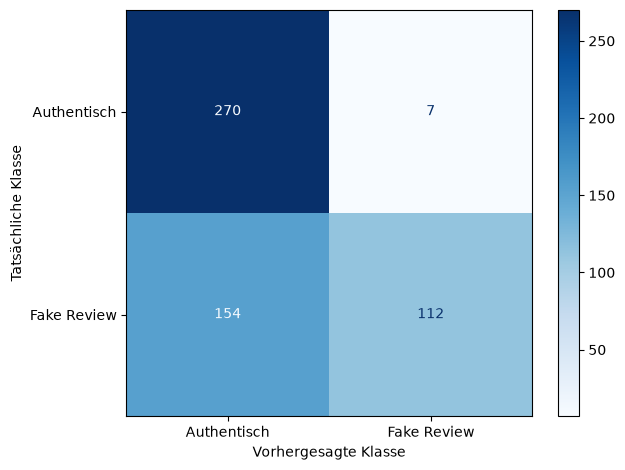

In [91]:
# Wahrscheinlichkeit für Fake Review (= Klasse 1)
test_probabilities = random_forest.predict_proba(X_test)[:, 1]

# Schwellenwert ist bereits festgelegt
y_test_pred = (test_probabilities >= 0.8).astype(int)

results = []

results.append({
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, test_probabilities),
})

results_df = pd.DataFrame(results)
display(results_df.round(4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Authentisch", "Fake Review"],
    cmap="Blues",
    values_format="d"
)

plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.tight_layout()
plt.show()

# Anwendung auf PC Monitore

In [80]:
monitor_reviews = pd.read_csv(OUTPUT_DIR / "sample" / "final.csv")

X_monitor = monitor_reviews[MODEL_FEATURE_COLUMNS]

# Wahrscheinlichkeit für Fake Review
monitor_probabilities = random_forest.predict_proba(
    X_monitor
)[:, 1]

# Final festgelegter Schwellenwert

monitor_predictions = (
    monitor_probabilities >= 0.8
).astype(int)

# Ergebnisse dem ursprünglichen DataFrame hinzufügen

monitor_reviews = monitor_reviews.copy()

monitor_reviews["fake_probability"] = monitor_probabilities
monitor_reviews["fake_prediction"] = monitor_predictions

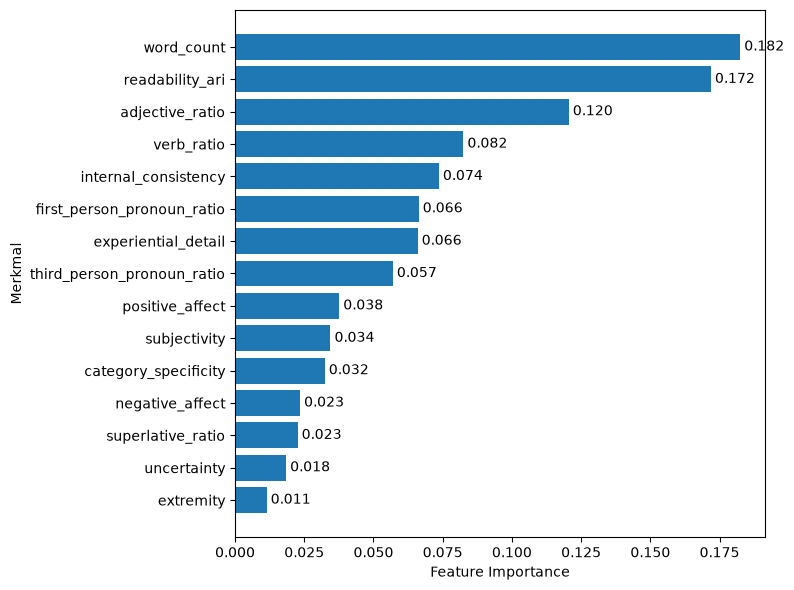

In [81]:
feature_importance = pd.DataFrame({
    "Merkmal": MODEL_FEATURE_COLUMNS,
    "Importance": random_forest.feature_importances_
}).sort_values(
    "Importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(
    feature_importance["Merkmal"],
    feature_importance["Importance"]
)

ax.bar_label(
    bars,
    fmt="%.3f",
    padding=3
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Merkmal")

plt.tight_layout()
plt.show()

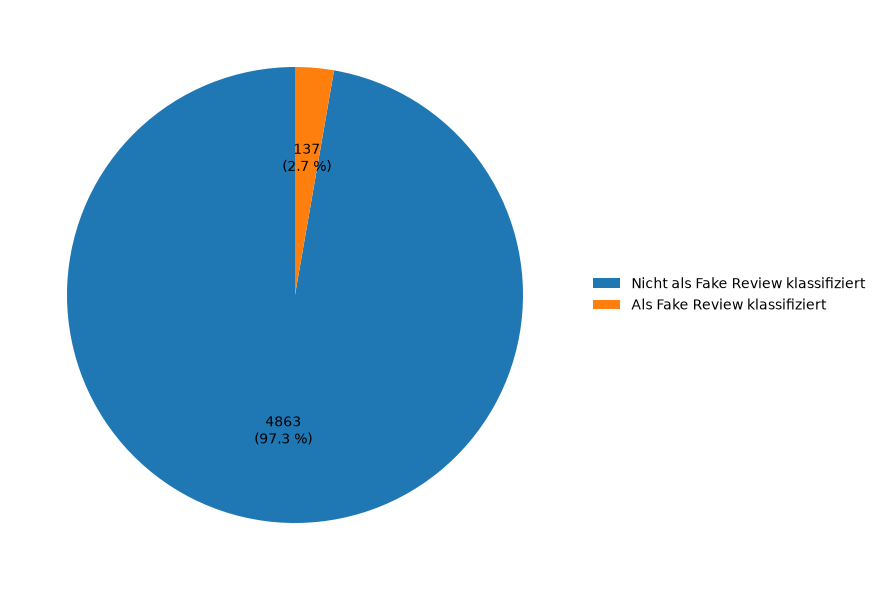

In [82]:
counts = monitor_reviews["fake_prediction"].value_counts()

labels = [
    "Nicht als Fake Review klassifiziert",
    "Als Fake Review klassifiziert"
]

values = [
    counts.get(0, 0),
    counts.get(1, 0)
]

total = sum(values)

def absolute_and_relative(pct):
    absolute = int(round(pct / 100 * total))
    return f"{absolute}\n({pct:.1f} %)"

fig, ax = plt.subplots(figsize=(9, 6))

wedges, texts, autotexts = ax.pie(
    values,
    autopct=absolute_and_relative,
    startangle=90
)

ax.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

,Kategorie,Ø Preis,Median Preis
0,Als Fake klassifiziert,268.82,209.79
1,Nicht als Fake klassifiziert,235.29,169.99
2,Gesamt,236.22,169.99


,price_quartile,Anzahl,Fake_Reviews,Fake_Anteil,Preis_Min,Preis_Max,Label
0,Q1,777,22,2.83,11.99,129.98,Q1\n12–130 €
1,Q2,774,17,2.20,129.99,169.99,Q2\n130–170 €
2,Q3,755,19,2.52,170.00,296.99,Q3\n170–297 €
3,Q4,761,27,3.55,299.00,2498.50,Q4\n299–2498 €


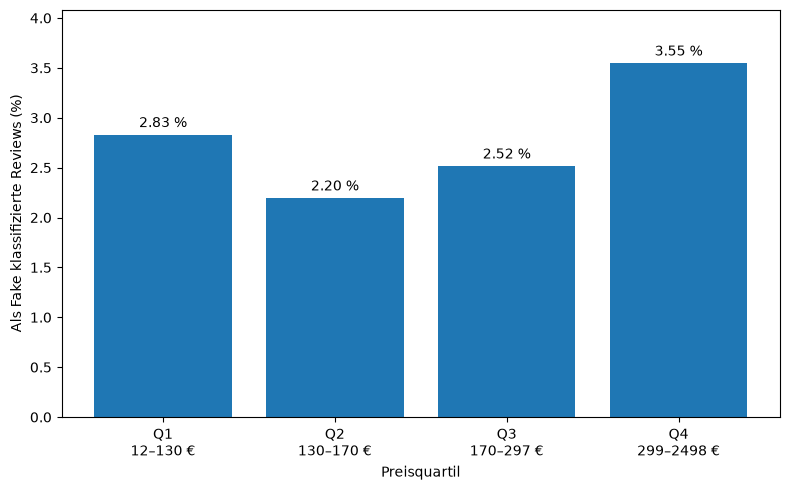

In [83]:
# -------------------------
# Preisvergleich der Gruppen
# -------------------------

fake_reviews = monitor_reviews[
    monitor_reviews["fake_prediction"] == 1
]

other_reviews = monitor_reviews[
    monitor_reviews["fake_prediction"] == 0
]

eval_price = [
    {
        "Kategorie": "Als Fake klassifiziert",
        "Ø Preis": fake_reviews["price"].mean(),
        "Median Preis": fake_reviews["price"].median()
    },
    {
        "Kategorie": "Nicht als Fake klassifiziert",
        "Ø Preis": other_reviews["price"].mean(),
        "Median Preis": other_reviews["price"].median()
    },
    {
        "Kategorie": "Gesamt",
        "Ø Preis": monitor_reviews["price"].mean(),
        "Median Preis": monitor_reviews["price"].median()
    }
]

eval_price_df = pd.DataFrame(eval_price)

display(eval_price_df.round(2))


# -------------------------
# Preisquartile bilden
# -------------------------

monitor_reviews["price_quartile"] = pd.qcut(
    monitor_reviews["price"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

price_quartiles = (
    monitor_reviews
    .groupby("price_quartile", observed=True)
    .agg(
        Anzahl=("fake_prediction", "size"),
        Fake_Reviews=("fake_prediction", "sum"),
        Fake_Anteil=("fake_prediction", "mean"),
        Preis_Min=("price", "min"),
        Preis_Max=("price", "max")
    )
    .reset_index()
)

price_quartiles["Fake_Anteil"] *= 100


# Beschriftung mit Quartil + Preisbereich
price_quartiles["Label"] = price_quartiles.apply(
    lambda row: (
        f"{row['price_quartile']}\n"
        f"{row['Preis_Min']:.0f}–{row['Preis_Max']:.0f} €"
    ),
    axis=1
)

display(price_quartiles.round(2))


# -------------------------
# Balkendiagramm
# -------------------------

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    price_quartiles["Label"],
    price_quartiles["Fake_Anteil"]
)

# Prozentwerte über den Balken
ax.bar_label(
    bars,
    labels=[
        f"{value:.2f} %"
        for value in price_quartiles["Fake_Anteil"]
    ],
    padding=3
)

ax.set_xlabel("Preisquartil")
ax.set_ylabel("Als Fake klassifizierte Reviews (%)")
# Etwas Platz oberhalb der Balken für Beschriftungen
ax.set_ylim(
    0,
    price_quartiles["Fake_Anteil"].max() * 1.15
)

plt.tight_layout()
plt.show()

In [84]:
# Abweichung der individuellen Bewertung
# vom Produktdurchschnitt
monitor_reviews["rating_deviation"] = (
    monitor_reviews["rating"]
    - monitor_reviews["average_rating"]
)

# Hat die Rezension mindestens eine Helpful Vote?
monitor_reviews["has_helpful_vote"] = (
    monitor_reviews["helpful_vote"] > 0
)

# Gruppen
not_fake = monitor_reviews[
    monitor_reviews["fake_prediction"] == 0
]

fake = monitor_reviews[
    monitor_reviews["fake_prediction"] == 1
]

comparison = pd.DataFrame({
    "Merkmal": [
        "Produktpreis (Median in €)",
        "Verifizierte Käufe (%)",
        "Mind. eine Helpful Vote (%)",
        "Produktpopularität (Median Ratings)",
        "Durchschnittliche Produktbewertung",
        "Abweichung vom Produktdurchschnitt (Median)"
    ],
    
    "Nicht als Fake klassifiziert": [
        not_fake["price"].median(),
        not_fake["verified_purchase"].mean() * 100,
        not_fake["has_helpful_vote"].mean() * 100,
        not_fake["rating_number"].median(),
        not_fake["average_rating"].mean(),
        not_fake["rating_deviation"].median()
    ],
    
    "Als Fake klassifiziert": [
        fake["price"].median(),
        fake["verified_purchase"].mean() * 100,
        fake["has_helpful_vote"].mean() * 100,
        fake["rating_number"].median(),
        fake["average_rating"].mean(),
        fake["rating_deviation"].median()
    ]
})

display(comparison.round(2))

,Merkmal,Nicht als Fake klassifiziert,Als Fake klassifiziert
0,Produktpreis (Median in €),169.99,209.79
1,Verifizierte Käufe (%),90.38,83.94
2,Mind. eine Helpful Vote (%),31.89,29.20
3,Produktpopularität (Median Ratings),1108.00,728.00
4,Durchschnittliche Produktbewertung,4.35,4.34
5,Abweichung vom Produktdurchschnitt (Median),0.40,0.30


In [85]:
verified_analysis = (
    monitor_reviews
    .groupby("fake_prediction")["verified_purchase"]
    .agg(["count", "mean"])
)

verified_analysis["mean"] *= 100

verified_analysis = verified_analysis.rename(
    columns={"mean": "Verified (%)"}
)

display(verified_analysis.round(2))

,count,Verified (%)
fake_prediction,,
0,4863,90.38
1,137,83.94


In [86]:
monitor_reviews["popularity_quartile"] = pd.qcut(
    monitor_reviews["rating_number"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

popularity_analysis = (
    monitor_reviews
    .groupby("popularity_quartile", observed=True)
    .agg(
        Anzahl=("fake_prediction", "size"),
        Fake_Reviews=("fake_prediction", "sum"),
        Fake_Anteil=("fake_prediction", "mean"),
        Ratings_Min=("rating_number", "min"),
        Ratings_Max=("rating_number", "max")
    )
    .reset_index()
)

popularity_analysis["Fake_Anteil"] *= 100

display(popularity_analysis.round(2))

,popularity_quartile,Anzahl,Fake_Reviews,Fake_Anteil,Ratings_Min,Ratings_Max
0,Q1,1253,36,2.87,1,244
1,Q2,1248,42,3.37,247,1104
2,Q3,1250,27,2.16,1106,3523
3,Q4,1249,32,2.56,3573,40868


In [87]:
monitor_reviews["rating_deviation_category"] = pd.cut(
    monitor_reviews["rating_deviation"],
    bins=[-float("inf"), -0.5, 0.5, float("inf")],
    labels=[
        "Unter Produktdurchschnitt",
        "Nahe Produktdurchschnitt",
        "Über Produktdurchschnitt"
    ]
)

deviation_analysis = (
    monitor_reviews
    .groupby("rating_deviation_category", observed=True)
    .agg(
        Anzahl=("fake_prediction", "size"),
        Fake_Reviews=("fake_prediction", "sum"),
        Fake_Anteil=("fake_prediction", "mean")
    )
    .reset_index()
)

deviation_analysis["Fake_Anteil"] *= 100

display(deviation_analysis.round(2))

,rating_deviation_category,Anzahl,Fake_Reviews,Fake_Anteil
0,Unter Produktdurchschnitt,1499,45,3.00
1,Nahe Produktdurchschnitt,2012,54,2.68
2,Über Produktdurchschnitt,1489,38,2.55


In [88]:
verified_analysis = (
    monitor_reviews
    .groupby("fake_prediction")["verified_purchase"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

verified_analysis["mean"] *= 100

verified_analysis = verified_analysis.rename(columns={
    "count": "Anzahl Reviews",
    "sum": "Verifizierte Käufe",
    "mean": "Anteil verifiziert (%)"
})

display(verified_analysis.round(2))

,fake_prediction,Anzahl Reviews,Verifizierte Käufe,Anteil verifiziert (%)
0,0,4863,4395,90.38
1,1,137,115,83.94


In [89]:
monitor_reviews["has_helpful_vote"] = (
    monitor_reviews["helpful_vote"] > 0
)

helpful_analysis = (
    monitor_reviews
    .groupby("fake_prediction")
    .agg(
        Anzahl=("helpful_vote", "size"),
        Mit_Helpful_Vote=("has_helpful_vote", "sum"),
        Anteil_mit_Helpful_Vote=("has_helpful_vote", "mean"),
        Durchschnitt=("helpful_vote", "mean")
    )
    .reset_index()
)

helpful_analysis["Anteil_mit_Helpful_Vote"] *= 100

display(helpful_analysis.round(2))

,fake_prediction,Anzahl,Mit_Helpful_Vote,Anteil_mit_Helpful_Vote,Durchschnitt
0,0,4863,1551,31.89,1.57
1,1,137,40,29.20,0.66


In [90]:
model_feature_comparison = (
    monitor_reviews
    .groupby("fake_prediction")[MODEL_FEATURE_COLUMNS]
    .agg(["mean", "median"])
    .round(3)
)

display(model_feature_comparison)

readability_ari        extremity        subjectivity         \
                           mean median      mean median         mean median   
fake_prediction                                                               
0                         4.985  4.535     0.733    1.0        0.561    0.5   
1                         7.006  6.583     0.642    1.0        0.534    0.5   

                experiential_detail        positive_affect         ...  \
                               mean median            mean median  ...   
fake_prediction                                                    ...   
0                             0.142  0.000           0.350  0.312  ...   
1                             0.264  0.286           0.362  0.333  ...   

                adjective_ratio        verb_ratio        superlative_ratio  \
                           mean median       mean median              mean   
fake_prediction                                                              
0                         0.120  0.092      0.190  0.195             0.002   
1                         0.132  0.119      0.175  0.172             0.000   

                       first_person_pronoun_ratio         \
                median                       mean median   
fake_prediction                                            
0                  0.0                      0.043  0.037   
1                  0.0                      0.041  0.043   

                third_person_pronoun_ratio         
                                      mean median  
fake_prediction                                    
0                                    0.036  0.025  
1                                    0.024  0.022  

[2 rows x 30 columns]